# 7차시 분류 사전과제
#### 조대흠

---


## 1.군집화란?

### 1-1 머신러닝: 비지도 학습

- 머신러닝: 인공지능의 한 분야로, 컴퓨터가 스스로 학습할 수 있도록 도와주는 알고리즘

    - 지도 학습: 문제와 정답을 모두 알려주고 공부시키는 방법

    - 비지도 학습: 답을 가르쳐주지 않고 공부시키는 방법

- 비지도학습의 특징

    - 데이터 자체에 내재된 구조를 파악하여 학습

    - 정답 레이블이 없어, 모델의 성능을 명확히 측정 불가능

    - 표현 학습을 통해 데이터셋의 고유 패턴 식별

    - 데이터에서 새로운 특성을 찾는 목적 수행에 적합

- 비지도 학습이 적합한 케이스

    - 패턴이 아직 알려지지 않은 경우

    - 패턴이 계속해서 변하는 경우

    - 열린 문제를 해결하고 지식을 일반화

    - ex) 자연어 처리, 고객 세그먼트 분석, 이상 거래 탐지


### 1-2 군집화란?

- 군집화: 데이터를 비슷한 특성을 가진 그룹으로 나누는 비지도 학습 기법
    - 군집: 유사한 데이터들의 집합. 이때, 서로 다른 군집에 속한 개체들은 비슷하면 안됨

- 비지도학습: 군집화
    - 군집화는 종속 변수를 설정하지 않고, 데이터 내부의 패턴을 인식해 그룹으로 나누는 것
    - 따라서 비지도 학습

- 군집화의 목표

    - 응집도 최대화: 같은 군집에 속하는 데이터끼리는 최대한 비슷해야함

    - 분리도 최대화: 서로 다른 군집은 최대한 분리되어야 함

    - 데이터간의 유사성을 최대한 유지하며, 다른 그룹과는 구분되도록 하는 것이 목표


### 1-3 군집화 과정

- 군집화의 기본 과정
    - 피처선택(특징 선택) -> 군집화 알고리즘 선택(데이터의 특성, 목표 따른 알고리즘 선택) -> 군집 유효성 검증(군집화가 잘되었는지 평가) -> 결과 해석


--- 

## 2.군집화를 위한 데이터 준비

### 2-1 군집화의 주요 고려사항

- 군집화는 한 번으로 끝나는 것이 아니라, 여러번의 반복 시도를 통해 최적의 결과를 찾아내는 과정

#### 효과적인 군집화를 위한 주요 사항

a. 변수 유형 이헤: 피처의 종류와 특성을 명확하게 이해 / 변수의 종류, 개수 파악
b. 거리/유사도 정의와 측정: 거리 또는 유사도 기반으로 그룹 형성 / 거리 측정 방법에 대한 정의가 중요
c. 차원 축소: 유사한 변수들을 묶어 처리하는 차원 축소 고려


### 2-2 변수 유형 이해

- 변수 유형에 따라 거리 측정법 과 알고리즘이 달라짐

a. 연속형 변수

    - 수치로 측정 가능한 변수
    - 거리측정: 유클리디안 거리, 맨하탄 거리 사용
    - 알고리즘: K-means, 계층적 군집화
    - 스케일링 필수

b. 명목형 변수

    - 범주로 구분되는 변수
    - 거리측정: 해밍 거리, 자카드 거리
    - 알고리즘: K-modes, 계층적 군집화
    - 원-핫 인코딩 또는 더미 변수 변환

c. 혼합형 변수

    - 연속형과 명목형이 섞인 데이터
    - K-prototypes, Gower distance 기반 계층적 군집화
    - 처리 방법: 각 변수 유형에 맞는 거리 함수 조합


### 2-3 거리/유사도 정의와 측정

- 데이터의 거리 측정법: 군집화에서 데이터 포인트나 군집간의 유사성과 비유사성을 수치로 계산

a. 유클리디안 거리

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2} $$
    - 직선거리를 의미, K-means에서 사용

b. 맨하탄 거리

$$ d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i| $$

    - 각 차원의 차이의 절댓값의 합
    - 이상치에 덜 민감

c. 코사인 유사도

$$ \text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||} $$

    - 벡터간의 각도 측정
    - 텍스트 데이터, 고차원 데이터에 효과적

- 6가지 연결 방법: 계층적 군집화에서 두 군집간의 거리를 계산하는 방식

a. Single linkage

    - 군집 A, B사이의 가장 가까운 두 점 간 거리로 군집간 거리 정의
    - 두 군집 간 가장 가까운 두 점 사이의 거리를 측정하는 방법
    - 고립된 군집을 찾는데 중점
    - 이상치에 민감

b. Complete linkage

    - 군집 A, B사이의 가장 먼 두 점 간 거리
    - 군집에서 하나씩 관측값을 뽑았을때 나타날 수 있는 거리의 최대값
    - 군집의 내부 응집성에 중점을 둠
    - 이상치에 민감

c. Average linkage

    - 군집 A와 B의 모든 점 쌍 사이 거리의 평균
    - 모든 항목에 대한 거리 평균을 구함
    - 이상치에 덜 민감 but 계산량이 불필요하게 많아짐

d. Centroid Method

    - 두 군집의 중심 간의 거리 측정
    - 두 군집이 결합될 때 새로운 군집의 평균을 가중 평균을 통해 구함
    - 시간이 오래 걸림(중심계산)
    - 거리축이 줄어드는 inversion 발생 가능성

f. Median

    - 두 군집의 중앙값 사이의 거리
    - 합쳐지는 두 군집의 산술적 중간 지점을 새로운 대표값으로 설정
    - 데이터 중앙값에 기반해 군집 간 거리 정의

g. Ward's Procedure

    - 군집 내 제곱합이 증가하지 않도록 병합
    - 병합 후 군집 내 SSE의 증가분이 최소인 것을 선택

### 2-4 차원 축소

- 군집화에서 거리 기반 알고리즘의 경우, 데이터의 차원이 높을 수록 피처 공간이 너무 커 데이터를 효율적으로 훈련할 수 없음
- 이에 차원축소가 필요

- 차원이란? --> 차원이란 변수의 개수를 뜻함.
- 차원축소의 목표: 변수를 제거하여 차원을 낮춰, 핵심 정보는 지켜내되, 노이즈를 줄이는 것

- 차원 축소
    - 선형 투영: 고차원 공간에서 저차원 공간으로 선형적 데이터 투영
    - 매니폴드 학습(비선형 차원 축소): 유클리드 거리가 아닌 곡선 거리를 고려

- PCA: 가장 정보량의 분산이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하는 것
    - 분산을 최대한 보존하면서 차원을 줄임
    - 원본의 고차원 데이터에서 최대 분산 방향을 찾아 상관관계 감소, 저차원 공간에 이를 투영 --> 이를 주성분이라함

---

## 3.군집화 알고리즘

### 3-1 계층적 군집화

- 계층적 군집화: 데이터 간의 유사성을 기반으로 트리 구조 형성

- 계층적 군집화 특징
    - 데이터셋의 관측치를 사용해 덴드로그램 생성
    - 군집의 개수를 사전에 설정하지 않고, 클러스터링 종료 후 군집의 개수 선택 가능
    - 트리 구조에 따라 분리
        - 상향식 - 응집형 계층적 군집화
        - 하향식 - 분리형 계층적 군집화

- 응집형/분리형 계층적 군집화

    - 응집형 클러스터링: 각 샘플이 독립적인 클러스터가 됨.
    - 분할형 클러스터링: 전체 샘플을 포함한 하나의 클러스터에서 시작해, 유사성이 낮은 데이터들을 더 작은 클러스터로 나눔
    - 이 두 클러스터링 모두 거리행렬, 유사도행렬에 따라 조직화

- 응집형 계층적 군집화
    - 모든 데이터 포인트를 각각 하나의 클러스터로 간주
    - 가장 가까운 클러스터의 정의에 따라 다양한 알고리즘으로 나뉨
    - 단일연결 / 완전연결 방식이 대표적

- 계층적 군집화 시각화

    - 덴드로그램을 통해 클러스터를 요약해서 확인 가능
    - 계산량이 많아, 소규모 데이터에 대해 탐색할때 용이


### 3-2 K-means

- 데이터를 정해진 K개의 그룹으로 나누되, 각 그룹의 중심점과 거리가 가장 가까운 데이터끼리 묶는 알고리즘

- 연속적인 데이터 샘플 중, 군집 중심점을 선택해 중심에 가장 가까운 데이터를 묶어나가는 기법

- K-means의 주요 단계
    1. 표본들 중 랜덤하게 k개의 중심점 선택
    2. 각 표본들을 가장 가까운 중심점에 할당
    3. 각 클러스터에 할당된 표본들의 데이터 평균을 계산해 중심점 이동
    4. 허용 오차, 최대 반복횟수 도달할때까지 2,3번 반복

- k-means의 장단점
    - k-means의 장점: 직관적, 구현 쉬움, 대용량 데이터에 적용 가능
    - k-means의 단점: 초기 centroid에 민감, k결정 어려움, 아웃라이어에 민감

- k-means++ 알고리즘
    - 초기 중심점들을 서로 멀리 떨어진 곳에 위치
    - 초기 중심점을 랜덤하게 할당
    1. 선택한 k개의 중심점을 저장할 빈집합 M
    2. M에 없는 샘플에 대해 M의 중심점까지의 최소 제곱 거리 찾음
    3. 가중치가 적용된 확률 분포 사용하여 다음 중심점 선택
    4. 반복 후 k-means알고리즘 수행



- 엘보우 방법
    - 클래스 내 SSE를 바탕으로 그래프 활용해 최적 클러스터 개수 추정
    - k값을 바꾸어가며 클러스터링 진행, 
    - 장점: 직관적, 구현이 쉬움
    - 단점: 주관적 판단, 모호한 경우존재

### 3-3 DBSCAN

- DBSCAN: 밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하면 군집에 포함 X
- 이상치로 부터 자유로우며, 특정 거리내에 있으면 가장 밀도가 높은 군집과 그룹화 가능
- 1. 샘플분류
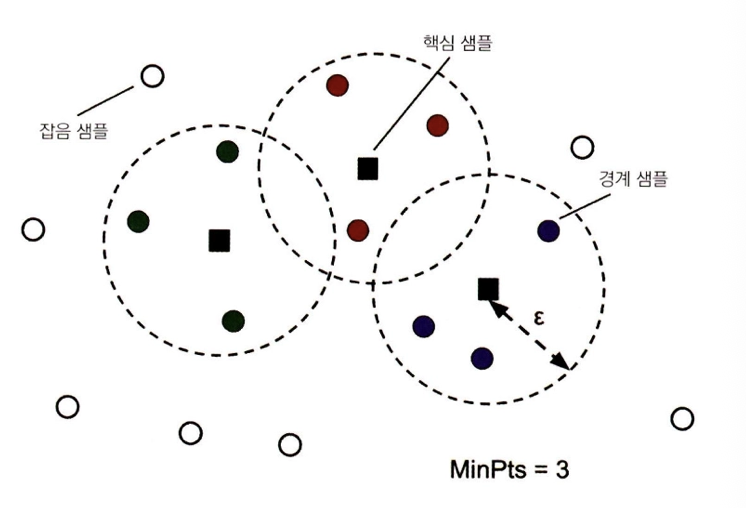
    - 핵심샘플(특정 반경내 이웃 샘플이 지정된 개수 이상인 경우)
    - 경계샘플(특정 반경 이내에 MinPts보다 이웃이 적지만, 다른 핵심 샘플의 반경에 있는 경우)
    - 잡음샘플(위 두 조건 모두 미충족)

- 2. 클러스터 생성
    - 개별 핵심 샘플 또는 반경이내에 있는 핵심 샘플을 연결한 그룹을 클러스터로 생성

- 3. 경계 샘플 할당
    - 경계 샘플을 해당 샘플의 클러스터에 할당

- 장점: 이상치에 민감하지 않음, 임의의 기하학적 분포를 갖는 데이터 처리 용이, 모든 샘플을 클러스터에 할당하지 않음
- 단점: 설정에 많은 영향을 받음, epsilon을 조정하는데는 도메인 지식 필요, 연산ㄴ량이 많고, 차원의 저주 영향 받음

- HDBSCAN : 계층적 DBSCAN
    - 밀도 기반으로 1차 군집화
    - 거리 기준으로 밀도 기반 군집들을 반복적으로 연결

- 장점: 여러 밀도 기준으로 반복 수행 / 단일 밀도 기준 한계 보완


### 3-4 Gaussian Mixture Model

- 데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정, 각 분포를 클러스터로 인식
- 특징:
    - 모델 기반 군집화 방법: 데이터를 생성하는 통계적 모델 가정 / 데이터가 해당 모델로부터 생성되었다는 전제하에 수행
    - 각 군집을 확률분포로 간주
    - 여러 확률 분포의 혼합으로 모델링
    - 데이터 생성 메커니즘까지 모델링 가능

- 가정:
    - 관측된 데이터는 특정 가우시안 확률 분포에 의해 생성 , 전체 데이터셋에는 여러개의 분포가 섞임, 개별데이터는 우도에 따라 K개의 가우시안 분포 중 하나에 속함

- GMM의 진행 과정
    1. 주어진 전체 데이터셋의 분포 확인
    2. 서로 다른 정규 분포 형태의 확률 분포 곡선으로 구성되었다 가정
    3. 전체 데이터셋 구성하는 여러개의 정규분포 곡선 추출

- 모델 파라미터 추정
    - 기댓값 최대화 알고리즘 사용
    1. Initialization: 필요 파라미터 $$u, \Sigma, \pi$$ 초기값 선정
    2. Expectation step: 현재 $$\theta$$를 통해 x가 특정 분포에 속할 확률 계산
    3. Maximization step: 계산된 사후 확률 통해 파라미터 다시 추정
    4. 수렴 조건 만족까지 반복

- GMM의 장단점
    - 장점: 다양한 데이터 셋에 적용 가능, K-means 작동하지 않는 타원형 분포, 중첩된 군집 구조에서도 좋은 성능
    - 단점: 군집화를 위한 시간이 오래 걸림, 분포와 맞지 않는 데이터일 경우 성능 저하

---

## 4.군집화 평가 방법

### 4-1 외부 평가와 내부 평가

- 정답 레이블의 유무에 따라 외부 평가와 내부평가로 나뉨

- 외부평가
    - 데이터에 정답 레이블이 존재하는 경우에 사용
    - 군집화 결과와 실제 레이블을 비교
    - ARI지표 사용: 군집화 결과와 실제 레이블간 일치도

- 내부평가
    - 정답레이블이 없는 경우에 사용
    - 군집 내부 응집도와 군집간 분리도를 기반으로 측정
    - K-means 알고리즘: SSE 최소화
    - GMM: 로그우드 최대화
    - 실루엣 계수, 던 지수 등 대표적 지표 존재

### 4-2 실루엣 계수

- 실루엣 계수: 클러스터 내 샘플들이 얼마나 조밀하게 모여 있는지 측정

- 실루엣 계수 계산:
$$ s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}}$$
    - 샘플과 동일한 클러스터 내 모든 다른 포인트 사이의 거리를 평균하여 응집력 계산
    - 샘플과 가장 가까운 클러스터의 모든 샘플간 평균 거리로 클러스터 분리도 계산
    - 클러스터 분리도에서 응집도를 뺀 값을 둘 중 더 큰 값으로 나누어 실루엣 계산

- 실루엣 계수 해석:
    - -1과 1사이 값을 가짐
    - 분리도가 응집도보다 큰 경우 이상적인 실루엣 계수인 1에 가까워짐 -> 0.7 이상일시 군집화 잘 됬다 해석
    - 분리도와 응집도가 같을 경우 실루엣 계수는 0지 -> 군집간 거리 모호
    - 분리도가 응집도보다 작은 경우 -1에 가까워짐 -> 군집화가 잘 안됨


### 4-3 Dunn Index

- Dunn Index: 클러스터 간 최소 거리(분리도)와 클러스터 내 최대거리(응집도)의 비율을 계산

- Dunn Index
$$ \text{Dunn Index} = \frac{\min\limits_{i \ne j} \; d(C_i, C_j)}{\max\limits_{1 \le k \le K} \; \delta(C_k)} $$
    - 분자: 두 클러스터 사이의 거리
    - 분모: 클러스터 내의 최대 거리

- Dunn Index 해석
    - 값이 클수록 좋은 군집화 결과 의미 -> 분리도가 높으며 응집도가 높음
    - 0이상의 값을 가지며 무한대까지 늘어남
    - 실루엣 계수와 종합적 평가 권장

- Dunn Index 한계
    - 군집수 많아질수록 계산 비용 증가
    - 극단적인 값에 큰 영향을 받음
    - 이상치에 민감하게 반응